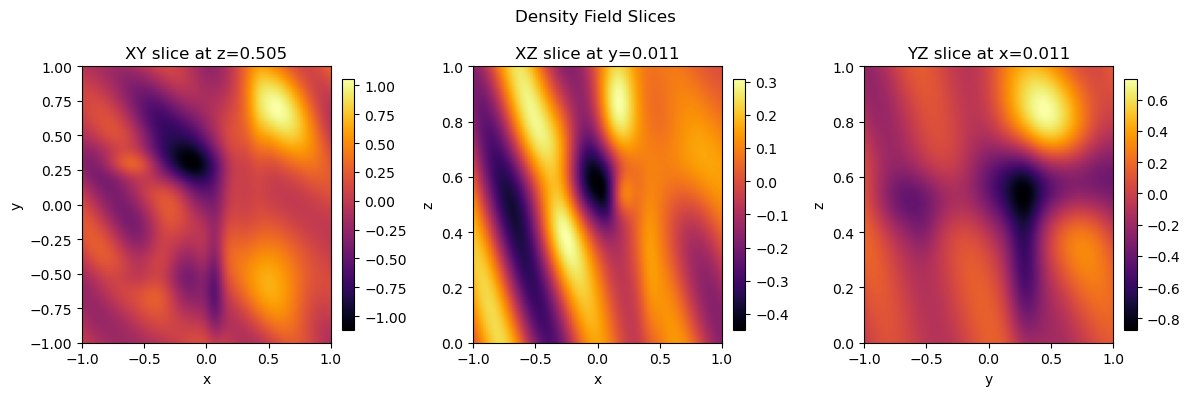

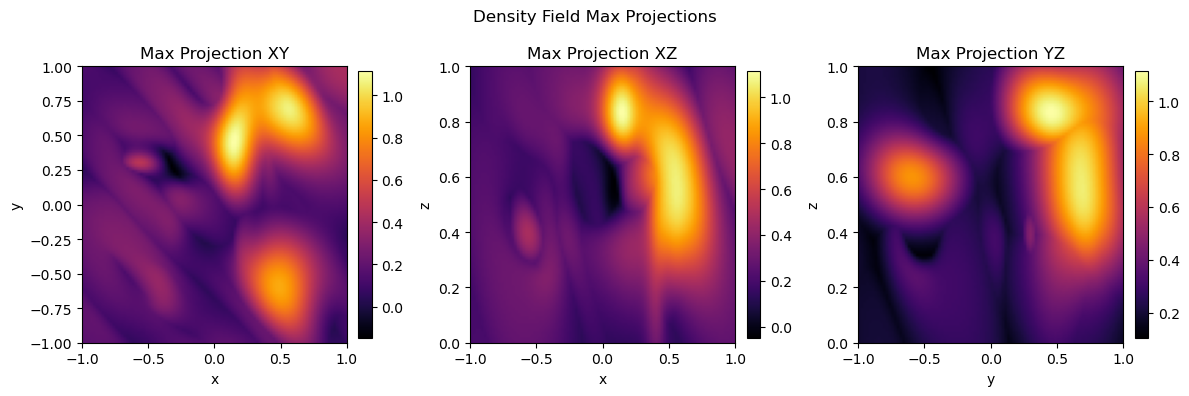

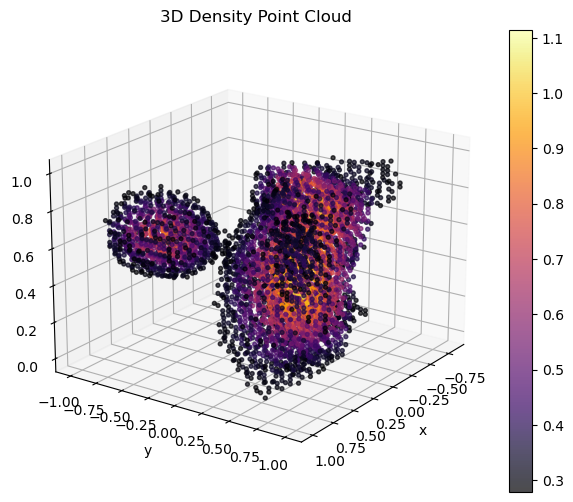

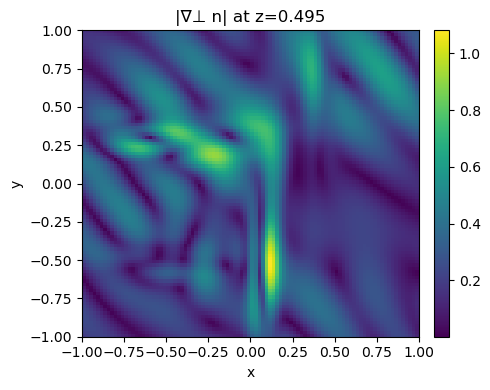

(<Figure size 500x400 with 2 Axes>,
 <Axes: title={'center': '|∇⊥ n| at z=0.495'}, xlabel='x', ylabel='y'>)

In [5]:
from sim.fields import GaussianBlob, RandomGaussianMixtureField
from sim.visualization import (
    plot_density_slices,
    plot_density_max_projections,
    plot_density_point_cloud,
    plot_transverse_gradient_magnitude,
)

field = RandomGaussianMixtureField(
    num_blobs=15,
    beta=0.15,
    seed=496,
    sinusoid_amplitude=0.12,
    num_sinusoids=3,
    z_mod_amplitude=0.25,
    z_mod_k=3.0,
)
plot_density_slices(field)
plot_density_max_projections(field)
plot_density_point_cloud(field, threshold_ratio=0.25)
plot_transverse_gradient_magnitude(field, slice_z=0.5)

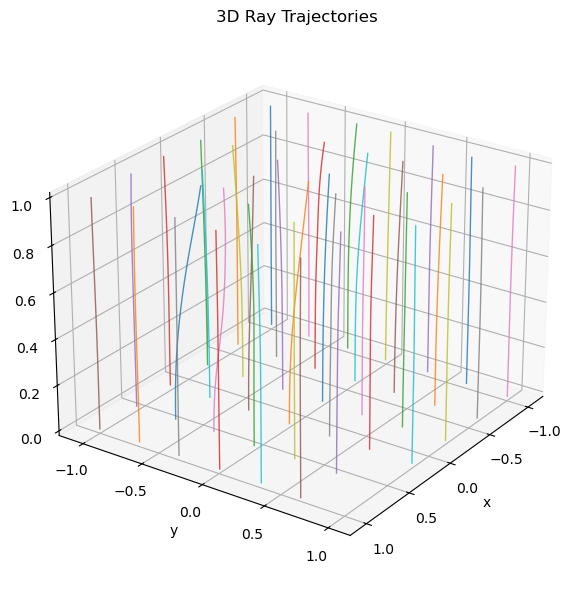

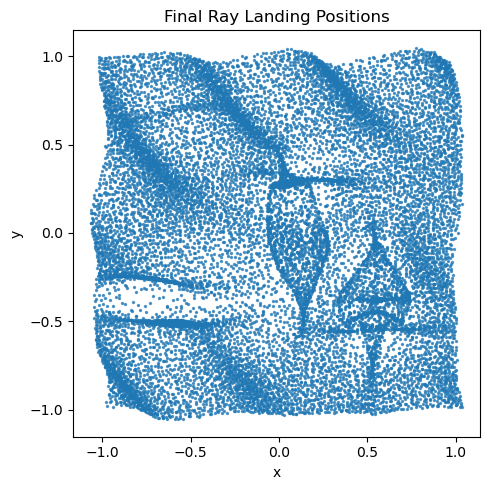

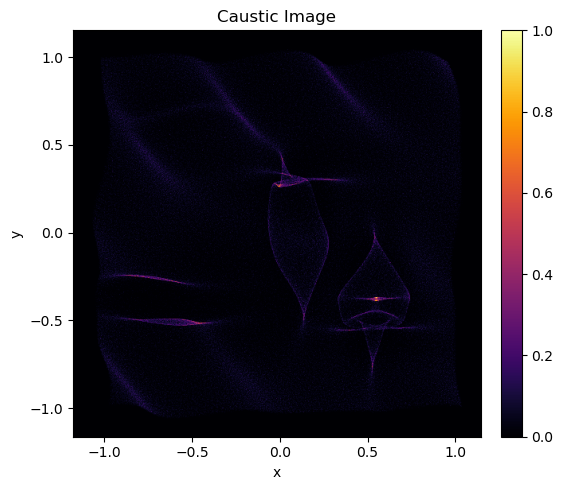

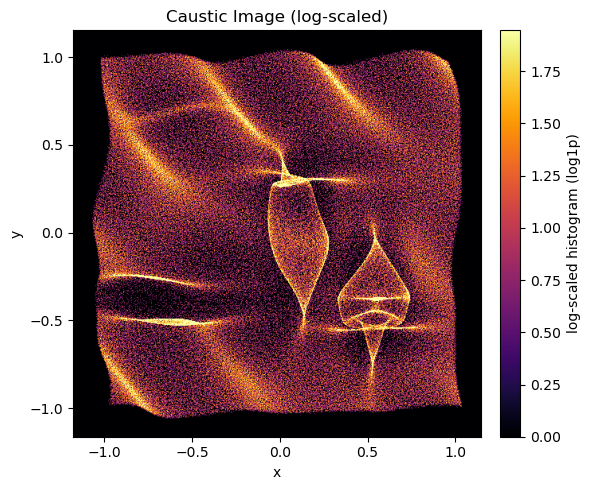

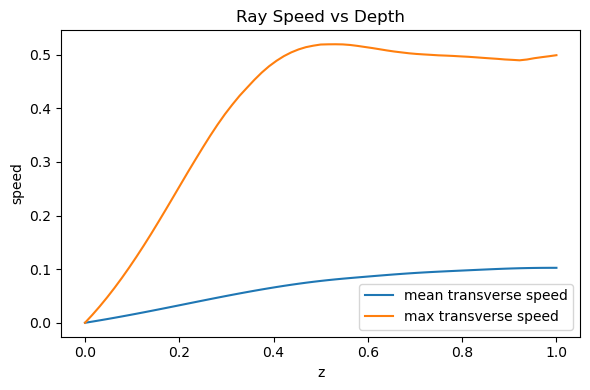

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Ray Speed vs Depth'}, xlabel='z', ylabel='speed'>)

In [11]:
import numpy as np

from sim.fields import GaussianBlob, SinusoidalField, RandomGaussianMixtureField
from sim.raytrace import make_entrance_rays, trace_rays_semi_implicit
from sim.visualization import (
    plot_final_ray_positions,
    plot_caustic,
    plot_caustic_log,
    plot_ray_trajectories_xz,
    plot_ray_trajectories_yz,
    plot_ray_trajectories_3d,
    plot_ray_speed,
)

field = RandomGaussianMixtureField(
    num_blobs=12,
    beta=0.16,
    seed=496,
    sinusoid_amplitude=0.06,
    num_sinusoids=3,
    z_mod_amplitude=0.25,
    z_mod_k=3.0,
)
x0, y0, vx0, vy0 = make_entrance_rays(
    nx=512, ny=512,
    xlim=(-1, 1),
    ylim=(-1, 1),
    vx0=0.0,
    vy0=0.0,
)
x0 += np.random.normal(scale=0.005, size=x0.shape)
y0 += np.random.normal(scale=0.005, size=y0.shape)

result = trace_rays_semi_implicit(
    field=field,
    x0=x0,
    y0=y0,
    vx0=vx0,
    vy0=vy0,
    zmax=1.0,
    num_steps=64,
    bend_scale=1.0,
    return_acceleration=True,
)

plot_ray_trajectories_3d(result, num_rays=40)
plot_final_ray_positions(result, num_rays = 128*128)
plot_caustic(result, bins=512)
plot_caustic_log(result, bins=512)
plot_ray_speed(result)